# Chronos2 Variable-Length Inference (Batch vs Individual)

This concise example compares batched and individual inference for variable-length inputs using `Chronos2Model`.

In [1]:
import numpy as np

import datasets
from darts.datasets import AirPassengersDataset
from darts.models import TimesFM2p5Model

datasets.disable_progress_bars()

N = 5  # forecast horizon
ATOL = 2e-5

c:\projects\darts\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = AirPassengersDataset().load().astype(np.float32)

# Variable-length inference inputs (different history lengths).
series_list = [
    data[0:24],
    data[5:20],
    data[10:18],
    data[18:30],
]

MAX_INPUT_LENGTH = max(len(s) for s in series_list)

print("Input lengths:", [len(s) for s in series_list])
print("MAX_INPUT_LENGTH:", MAX_INPUT_LENGTH)

Input lengths: [24, 15, 8, 12]
MAX_INPUT_LENGTH: 24


In [3]:
def _left_pad_to_length(ts, target_len):
    pad_len = target_len - len(ts)
    if pad_len <= 0:
        return ts
    pad_values = np.full(
        (pad_len, ts.n_components, ts.n_samples),
        np.nan,
        dtype=ts.dtype,
    )
    return ts.prepend_values(pad_values)


def _compare_predictions(pred_a, pred_b, atol=1e-6):
    max_abs_diffs = []
    is_close = []
    for pa, pb in zip(pred_a, pred_b):
        va = pa.all_values(copy=False)
        vb = pb.all_values(copy=False)
        diff = np.max(np.abs(va - vb))
        max_abs_diffs.append(float(diff))
        is_close.append(bool(np.allclose(va, vb, atol=atol, rtol=0.0)))
    return max_abs_diffs, is_close


def compare_three_inference_modes(model, series, n, atol=1e-6):
    # 1) Raw batch with variable lengths.
    pred_batch_raw = model.predict(n=n, series=series)

    # 2) Batch with explicit left-NaN padding to a shared length.
    common_len = max(len(s) for s in series)
    series_padded = [_left_pad_to_length(s, common_len) for s in series]
    pred_batch_padded = model.predict(n=n, series=series_padded)

    # 3) Independent 1-by-1 predictions on raw (unpadded) series.
    pred_individual_raw = [model.predict(n=n, series=s) for s in series]

    diffs_1_vs_2, close_1_vs_2 = _compare_predictions(
        pred_batch_raw, pred_batch_padded, atol=atol
    )
    diffs_1_vs_3, close_1_vs_3 = _compare_predictions(
        pred_batch_raw, pred_individual_raw, atol=atol
    )

    return {
        "pred_batch_raw": pred_batch_raw,
        "pred_batch_padded": pred_batch_padded,
        "pred_individual_raw": pred_individual_raw,
        "diffs_1_vs_2": diffs_1_vs_2,
        "close_1_vs_2": close_1_vs_2,
        "diffs_1_vs_3": diffs_1_vs_3,
        "close_1_vs_3": close_1_vs_3,
    }

In [8]:
chronos = TimesFM2p5Model(
    input_chunk_length=None,
    output_chunk_length=2,
)
chronos.fit(series=series_list, verbose=False)

comparison = compare_three_inference_modes(chronos, series_list, n=N, atol=ATOL)

pred_batch_raw = comparison["pred_batch_raw"]
pred_batch_padded = comparison["pred_batch_padded"]
pred_individual_raw = comparison["pred_individual_raw"]

{
    "batch_raw_vs_batch_padded": {
        "allclose": all(comparison["close_1_vs_2"]),
        "allclose_per_series": comparison["close_1_vs_2"],
        "max_diff": max(comparison["diffs_1_vs_2"]),
    },
    "batch_raw_vs_individual_raw": {
        "allclose": all(comparison["close_1_vs_3"]),
        "allclose_per_series": comparison["close_1_vs_3"],
        "max_diff": max(comparison["diffs_1_vs_3"]),
    },
}

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 12.23it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 12.71it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 13.52it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 13.79it/s]


{'batch_raw_vs_batch_padded': {'allclose': True,
  'allclose_per_series': [True, True, True, True],
  'max_diff': 0.0},
 'batch_raw_vs_individual_raw': {'allclose': False,
  'allclose_per_series': [False, False, True, True],
  'max_diff': 0.0001068115234375}}

In [9]:
print(
    "batch_raw_vs_batch_padded:",
    f"allclose={all(comparison['close_1_vs_2'])},",
    f"max_diff={max(comparison['diffs_1_vs_2']):.8f},",
    f"per_series={comparison['close_1_vs_2']}",
)

print(
    "batch_raw_vs_individual_raw:",
    f"allclose={all(comparison['close_1_vs_3'])},",
    f"max_diff={max(comparison['diffs_1_vs_3']):.8f},",
    f"per_series={comparison['close_1_vs_3']}",
)

batch_raw_vs_batch_padded: allclose=True, max_diff=0.00000000, per_series=[True, True, True, True]
batch_raw_vs_individual_raw: allclose=False, max_diff=0.00010681, per_series=[False, False, True, True]


In [10]:
summary = {
    "batch_raw_vs_batch_padded": {
        "allclose": all(comparison["close_1_vs_2"]),
        "max_diff": max(comparison["diffs_1_vs_2"]),
        "allclose_per_series": comparison["close_1_vs_2"],
    },
    "batch_raw_vs_individual_raw": {
        "allclose": all(comparison["close_1_vs_3"]),
        "max_diff": max(comparison["diffs_1_vs_3"]),
        "allclose_per_series": comparison["close_1_vs_3"],
    },
}
summary

{'batch_raw_vs_batch_padded': {'allclose': True,
  'max_diff': 0.0,
  'allclose_per_series': [True, True, True, True]},
 'batch_raw_vs_individual_raw': {'allclose': False,
  'max_diff': 0.0001068115234375,
  'allclose_per_series': [False, False, True, True]}}

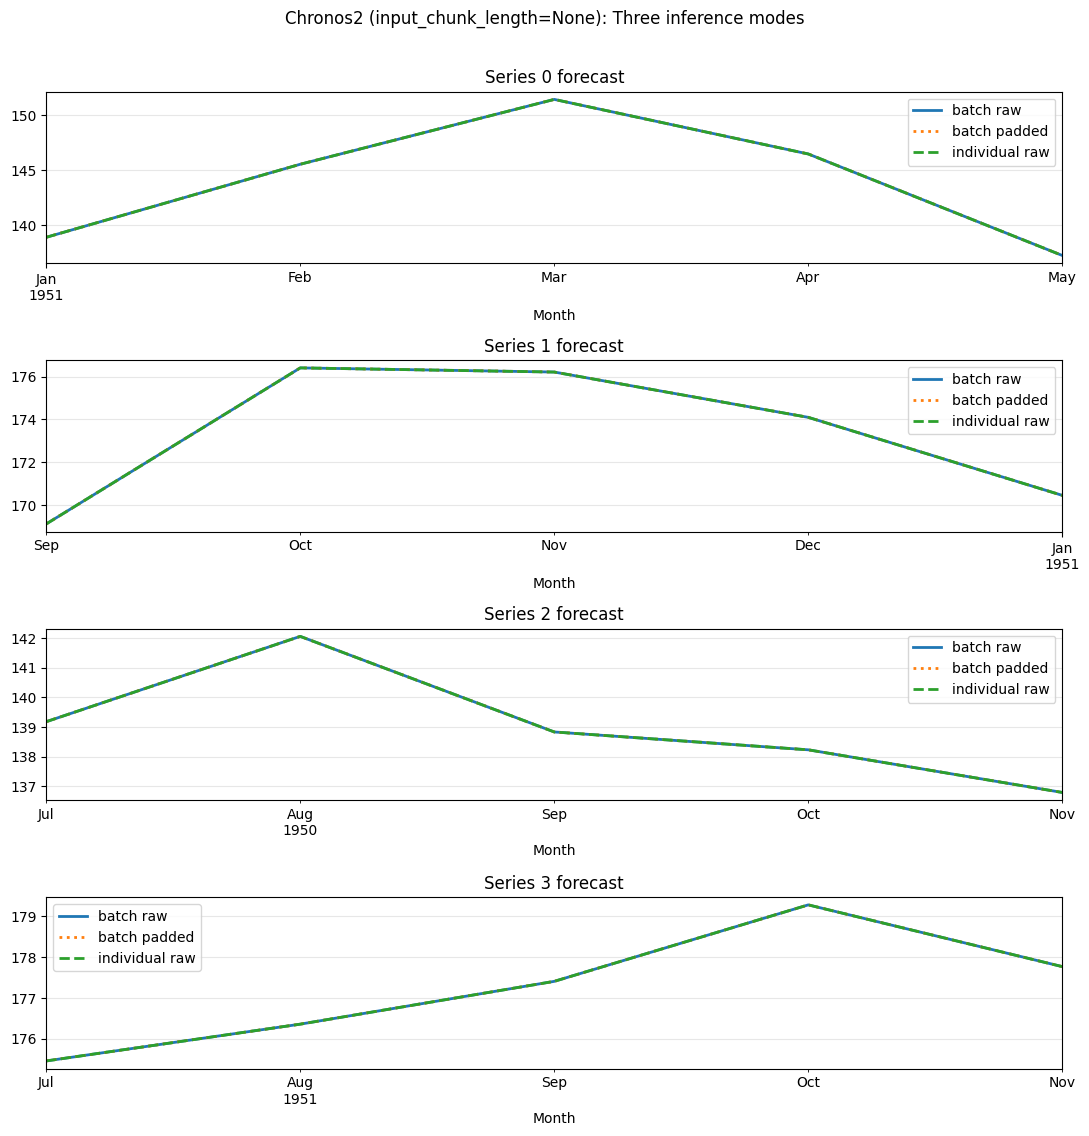

In [11]:
import matplotlib.pyplot as plt

n_rows = len(series_list)
fig, axes = plt.subplots(n_rows, 1, figsize=(11, 2.8 * n_rows), squeeze=False)

for i, (p1, p2, p3) in enumerate(
    zip(pred_batch_raw, pred_batch_padded, pred_individual_raw)
):
    ax = axes[i, 0]
    p1.plot(ax=ax, label="batch raw", linewidth=2.0)
    p2.plot(ax=ax, label="batch padded", linestyle=":", linewidth=2.0)
    p3.plot(ax=ax, label="individual raw", linestyle="--", linewidth=2.0)
    ax.set_title(f"Series {i} forecast")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")

fig.suptitle("Chronos2 (input_chunk_length=None): Three inference modes", y=1.01)
fig.tight_layout()
plt.show()

Interpretation:

- Three inference modes are compared:
  1) raw batch on variable-length inputs `[[1,2,3], [4,5], [6,7,8,9]]` will internally be converted to `[[NaN,1,2,3], [NaN,NaN,4,5], [6,7,8,9]]`
  2) batch on manually left-padded inputs (directly give `[[NaN,1,2,3], [NaN,NaN,4,5], [6,7,8,9]]` to the model)
  3) raw 1-by-1 independent calls (give to the model indivual samples `[1,2,3]`, `[4,5]` and `[6,7,8,9]`)
- `batch_raw_vs_batch_padded` should be (near) identical because NaN padding and internal masking represent the same effective batched setup.
- `batch_raw_vs_individual_raw` can differ with `input_chunk_length=None` because each individual call may resolve a different context length.

The internal padding is done so that ICL is a multiple of the patch size (e.g. 16 for Chronos). Before that, there was a big difference between 1) and 3)